               timestamp holiday  tavg  tmin  tmax  prcp_x  snow  wspd_x  \
0    2023-11-30 00:00:00     NaN   0.8  -1.4   3.9    16.4   0.0     3.4   
1    2023-11-30 01:00:00     NaN   0.8  -1.4   3.9    16.4   0.0     3.4   
2    2023-11-30 02:00:00     NaN   0.8  -1.4   3.9    16.4   0.0     3.4   
3    2023-11-30 03:00:00     NaN   0.8  -1.4   3.9    16.4   0.0     3.4   
4    2023-11-30 04:00:00     NaN   0.8  -1.4   3.9    16.4   0.0     3.4   
...                  ...     ...   ...   ...   ...     ...   ...     ...   
8089 2024-11-11 11:00:00     NaN   6.8   5.7   7.7     4.6   0.0     3.1   
8090 2024-11-11 12:00:00     NaN   6.8   5.7   7.7     4.6   0.0     3.1   
8091 2024-11-11 13:00:00     NaN   6.8   5.7   7.7     4.6   0.0     3.1   
8092 2024-11-11 14:00:00     NaN   6.8   5.7   7.7     4.6   0.0     3.1   
8093 2024-11-11 15:00:00     NaN   6.8   5.7   7.7     4.6   0.0     3.1   

      wpgt_x  pres_x  ...  rhum  prcp_y  wspd_y  wpgt_y  pres_y  tsun  \
0       32.8  

17:19:30 - cmdstanpy - INFO - Chain [1] start processing
17:19:30 - cmdstanpy - INFO - Chain [1] done processing


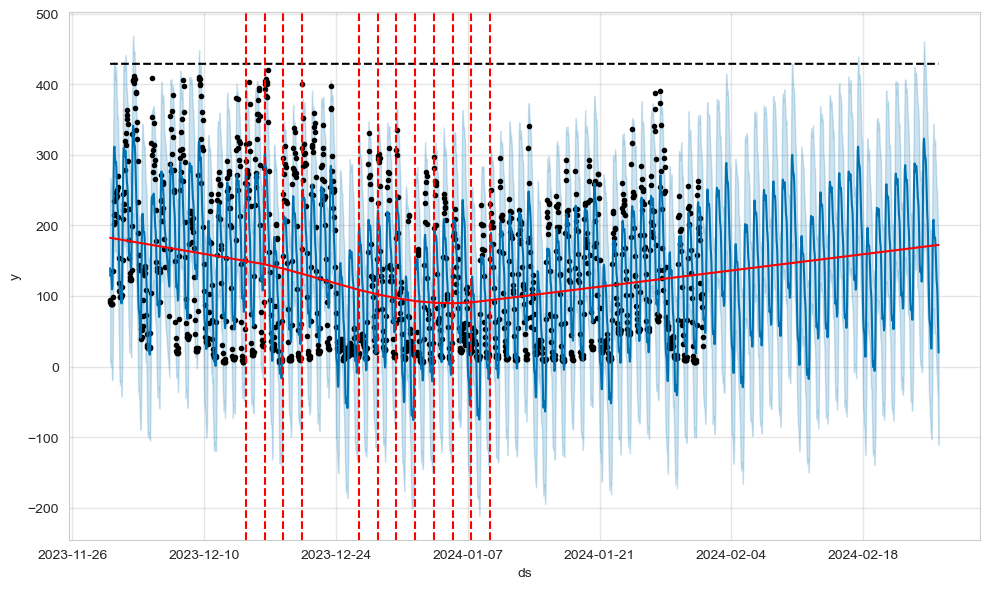

In [24]:
from meteostat import Point
import pandas as pd
from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly, add_changepoints_to_plot
import warnings
from meteostat import Hourly
from prophet.diagnostics import cross_validation, performance_metrics

warnings.simplefilter(action='ignore', category=FutureWarning)

data = pd.read_csv('./data/out_hourly.csv')
df = pd.DataFrame(data)

df['timestamp'] = pd.to_datetime(df['timestamp'])
start_date = pd.to_datetime('2023-11-30')
end_date = pd.to_datetime('2024-02-01')
df_p = df.copy()
df_p = df_p[(df_p['timestamp'] >= start_date) & (df_p['timestamp'] <= end_date)]

print(df)

#df_p = df[['timestamp', 'value']]
df_p = df_p.rename(columns={'timestamp': 'ds', 'value': 'y'})
df_p['cap'] = 429
df_p['floor'] = 0


df_events = df[['timestamp', 'event_name']]
df_events = df_events[df_events['event_name'].notna()]
df_events['ds'] = pd.to_datetime(df_events['timestamp']).dt.date
df_events = df_events.drop_duplicates(subset=['ds', 'event_name'])
df_events = df_events.drop('timestamp', axis=1)
df_chris = df_events[df_events['event_name'] == 'Christkindlemarkt']
df_events = df_events[df_events['event_name'] != 'Christkindlemarkt']

events = pd.DataFrame({
  'holiday': 'event',
  'ds': df_events['ds'],
  'lower_window': 0,
  'upper_window': 0,
})
chris = pd.DataFrame({
    'holiday': 'Christkindlemarkt',
    'ds': df_chris['ds'],
    'lower_window': 0,
    'upper_window': 0,
})
event_dates = pd.concat((chris, events))
m = Prophet( weekly_seasonality=True, holidays=event_dates, changepoint_prior_scale=0.1, seasonality_prior_scale=0.1, holidays_prior_scale= 0.01, interval_width=0.95)
m.add_seasonality(name='weekly', period=168, fourier_order=3, prior_scale=0.2)
def weather_sun(ds):
    date = pd.to_datetime(ds)
    row1 = df_p[df_p['ds'] == date]

    if not row1.empty and row1['tsun'].iloc[0] > 0:
        return 1
    else:
        return 0

def weather_hum(ds):
    date = pd.to_datetime(ds)

    row1 = df_p[df_p['ds'] == date]

    if not row1.empty and row1['rhum'].iloc[0] > 0:
        return -1
    else:
        return 0

df_p['sun'] = df_p['ds'].apply(weather_sun)
df_p['hum'] = df_p['ds'].apply(weather_hum)
m.add_regressor('sun')
m.add_regressor('hum')
m.add_country_holidays(country_name='AT')
m.fit(df_p)

future = m.make_future_dataframe(periods=600, freq='H')
future['cap'] = 429
future['floor'] = 0

future['sun'] = future['ds'].apply(weather_sun)
future['hum'] = future['ds'].apply(weather_hum)
forecast = m.predict(future)


fig1 = m.plot(forecast)
a = add_changepoints_to_plot(fig1.gca(), m, forecast)
plot_plotly(m, forecast)


In [46]:
import plotly.graph_objects as go
import plotly.offline as py

data = pd.concat([forecast, df_p['y']], axis=1)

start_date = pd.to_datetime('2024-02-02')
end_date = pd.to_datetime('2024-02-26')
df_f = df[(df['timestamp'] >= start_date) & (df['timestamp'] <= end_date)]
df_f = df_f.rename(columns={'timestamp': 'ds'})
data = pd.concat([data, df_f], ignore_index=True)


pred = go.Scatter(
    name="Prediction",
    x = data['ds'],
    y = data['yhat'],
    mode = 'lines',
    marker=dict(color="#0072B2")
)

real = go.Scatter(
    name="Real",
    x = data['ds'],
    y = data['y'],
    mode='markers',
    marker=dict(color="#000000")
)

real_future = go.Scatter(
    name="RealFuture",
    x = data['ds'],
    y = data['value'],
    mode='markers',
    marker=dict(color="#ff0000")
)

trend = go.Scatter(
    name = 'Trend',
    x = data['ds'],
    y = data['trend'],
    mode = 'lines',
    marker=dict(color="#ff0000")
)

upper_bound = go.Scatter(
    name = 'Upper Bound',
    mode = 'lines',
    x = data['ds'],
    y = data['yhat_upper'],
    marker=dict(color="#0072B2"),
    line=dict(width=.5),
    fill = 'tonexty'
)

lower_bound = go.Scatter(
    name= 'Lower Bound',
    mode = 'lines',
    x = data['ds'],
    y = data['yhat_lower'],
    marker=dict(color="#0072B2"),
    line=dict(width=.1),
)

traces = [pred, real, real_future, trend, lower_bound, upper_bound]

layout = dict(title='Utilization',
             plot_bgcolor='white',
             hovermode='x',
             width=1400,
             height=900,
             margin=dict(l=40, r=20, t=60, b=40),
             xaxis=dict(title = 'Date', ticklen=1, tick0=0, automargin=True, zeroline=True, linecolor='black', gridcolor='lightgrey', rangeslider=dict(visible=True), rangeslider_range=[data['ds'].min(), data['ds'].max()], dtick="D1", tickformat='%d.%m.%Y',  anchor='y', range=[data['ds'].min(), data['ds'].max()]),
             yaxis=dict(title = 'Parking spots', ticklen=1, tick0=0, automargin=True, zeroline=True, linecolor='black', gridcolor='lightgrey', anchor='x')
)

figure=dict(data=traces,layout=layout)

py.offline.iplot(figure)
